In [3]:
from google.colab import files
uploaded = files.upload()

Saving sat.trn to sat.trn
Saving sat.tst to sat.tst


In [4]:
import pandas as pd
# Load the training and test sets
X_train = pd.read_csv('sat.trn', delim_whitespace=True, header=None)
X_test  = pd.read_csv('sat.tst', delim_whitespace=True, header=None)

print(X_train.shape)
print(X_train.head())
print(X_test.shape)
print(X_test.head())

(4435, 37)
   0    1    2   3   4    5    6   7   8    9   ...   27  28   29   30   31  \
0  92  115  120  94  84  102  106  79  84  102  ...  104  88  121  128  100   
1  84  102  106  79  84  102  102  83  80  102  ...  100  84  107  113   87   
2  84  102  102  83  80  102  102  79  84   94  ...   87  84   99  104   79   
3  80  102  102  79  84   94  102  79  80   94  ...   79  84   99  104   79   
4  84   94  102  79  80   94   98  76  80  102  ...   79  84  103  104   79   

   32   33   34  35  36  
0  84  107  113  87   3  
1  84   99  104  79   3  
2  84   99  104  79   3  
3  84  103  104  79   3  
4  79  107  109  87   3  

[5 rows x 37 columns]
(2000, 37)
   0    1    2   3   4    5    6   7   8    9   ...  27  28   29   30  31  32  \
0  80  102  102  79  76  102  102  79  76  102  ...  87  79  107  109  87  79   
1  76  102  102  79  76  102  106  83  76  102  ...  87  79  107  113  87  79   
2  80   98  106  79  76   94  102  76  76   94  ...  79  79   95  100  79  79   


<ipython-input-4-349849840>:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv('sat.trn', delim_whitespace=True, header=None)
<ipython-input-4-349849840>:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test  = pd.read_csv('sat.tst', delim_whitespace=True, header=None)


In [5]:
# Split features and labels
y_train = X_train.iloc[:, -1]
X_train = X_train.iloc[:, :-1]

y_test = X_test.iloc[:, -1]
X_test = X_test.iloc[:, :-1]

print("X_train shape:", X_train.shape)
print("y_train distribution:\n", y_train.value_counts())
print("X_test shape:", X_test.shape)
print("y_test distribution:\n", y_test.value_counts())


X_train shape: (4435, 36)
y_train distribution:
 36
1    1072
7    1038
3     961
2     479
5     470
4     415
Name: count, dtype: int64
X_test shape: (2000, 36)
y_test distribution:
 36
7    470
1    461
3    397
5    237
2    224
4    211
Name: count, dtype: int64


In [6]:
print("Missing values in X_train:\n", X_train.isnull().sum().sum())
print("Missing values in X_test:\n", X_test.isnull().sum().sum())


Missing values in X_train:
 0
Missing values in X_test:
 0


In [7]:
print("Class distribution in y_train:\n", y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:\n", y_test.value_counts(normalize=True))


Class distribution in y_train:
 36
1    0.241714
7    0.234047
3    0.216685
2    0.108005
5    0.105975
4    0.093574
Name: proportion, dtype: float64

Class distribution in y_test:
 36
7    0.2350
1    0.2305
3    0.1985
5    0.1185
2    0.1120
4    0.1055
Name: proportion, dtype: float64


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)

# Train
model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred = model.predict(X_test_scaled)

# Evaluate
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Test Accuracy: 0.8395

Classification Report:
               precision    recall  f1-score   support

           1       0.97      0.98      0.98       461
           2       0.95      0.93      0.94       224
           3       0.86      0.93      0.89       397
           4       0.51      0.30      0.38       211
           5       0.84      0.76      0.80       237
           7       0.75      0.86      0.80       470

    accuracy                           0.84      2000
   macro avg       0.81      0.79      0.80      2000
weighted avg       0.83      0.84      0.83      2000



In [10]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Test Accuracy: 0.911

Random Forest Classification Report:
               precision    recall  f1-score   support

           1       0.98      0.99      0.99       461
           2       0.98      0.97      0.98       224
           3       0.89      0.95      0.92       397
           4       0.77      0.63      0.69       211
           5       0.92      0.91      0.92       237
           7       0.87      0.90      0.89       470

    accuracy                           0.91      2000
   macro avg       0.90      0.89      0.90      2000
weighted avg       0.91      0.91      0.91      2000



In [37]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize the scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both training and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create SVM classifier
svm_clf = SVC()

# Train the model on scaled data
svm_clf.fit(X_train_scaled, y_train)

# Predict on scaled test data
y_pred = svm_clf.predict(X_test_scaled)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Test Accuracy (scaled data): {accuracy:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))


SVM Test Accuracy (scaled data): 0.8955

Classification Report:
               precision    recall  f1-score   support

           1       0.98      1.00      0.99       461
           2       0.96      0.97      0.97       224
           3       0.87      0.96      0.92       397
           4       0.72      0.58      0.64       211
           5       0.93      0.86      0.89       237
           7       0.85      0.86      0.86       470

    accuracy                           0.90      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.89      0.90      0.89      2000



In [12]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model
gb_clf = GradientBoostingClassifier(random_state=42)

# Train the model
gb_clf.fit(X_train, y_train)

# Predict on the test set
y_pred_gb = gb_clf.predict(X_test)

# Evaluate
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Test Accuracy: {accuracy_gb:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_gb))


Gradient Boosting Test Accuracy: 0.8920
Classification Report:
              precision    recall  f1-score   support

           1       0.97      0.98      0.98       461
           2       0.97      0.97      0.97       224
           3       0.88      0.92      0.90       397
           4       0.69      0.61      0.65       211
           5       0.90      0.86      0.88       237
           7       0.86      0.88      0.87       470

    accuracy                           0.89      2000
   macro avg       0.88      0.87      0.87      2000
weighted avg       0.89      0.89      0.89      2000



In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize KNN with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Fit on scaled training data
knn.fit(X_train_scaled, y_train)

# Predict on scaled test data
y_pred_knn = knn.predict(X_test_scaled)

# Evaluate
print("KNN Test Accuracy (scaled data):", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))


KNN Test Accuracy (scaled data): 0.9045

Classification Report:
               precision    recall  f1-score   support

           1       0.98      0.99      0.99       461
           2       0.98      0.97      0.97       224
           3       0.89      0.93      0.91       397
           4       0.73      0.69      0.71       211
           5       0.92      0.87      0.90       237
           7       0.88      0.88      0.88       470

    accuracy                           0.90      2000
   macro avg       0.90      0.89      0.89      2000
weighted avg       0.90      0.90      0.90      2000



In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.7965

Classification Report:
               precision    recall  f1-score   support

           1       0.89      0.84      0.86       461
           2       0.98      0.89      0.93       224
           3       0.91      0.88      0.89       397
           4       0.49      0.67      0.57       211
           5       0.61      0.70      0.65       237
           7       0.84      0.75      0.79       470

    accuracy                           0.80      2000
   macro avg       0.79      0.79      0.78      2000
weighted avg       0.82      0.80      0.80      2000



In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize MLP (Neural Network)
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)

# Train
mlp.fit(X_train_scaled, y_train)

# Predict
y_pred_mlp = mlp.predict(X_test_scaled)

# Evaluate
print("Neural Network (MLP) Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("\nClassification Report:\n", classification_report(y_test, y_pred_mlp))


Neural Network (MLP) Accuracy: 0.904

Classification Report:
               precision    recall  f1-score   support

           1       0.98      0.99      0.98       461
           2       0.97      0.96      0.97       224
           3       0.89      0.93      0.91       397
           4       0.76      0.65      0.70       211
           5       0.89      0.90      0.90       237
           7       0.88      0.88      0.88       470

    accuracy                           0.90      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.90      0.90      0.90      2000



In [17]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Encode labels to one-hot vectors
num_classes = y_train.max()
y_train_oh = to_categorical(y_train - 1, num_classes=num_classes)
y_test_oh = to_categorical(y_test - 1, num_classes=num_classes)

# Convert X to float32 for Keras
X_train_keras = X_train_scaled.astype('float32')
X_test_keras = X_test_scaled.astype('float32')


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Assume X_train_keras, X_test_keras, y_train, y_test are defined
# y_train, y_test are original integer labels like 1,2,3,4,5,7

# 1. Encode y labels to 0-based indices to fit with to_categorical
unique_classes = np.unique(y_train)
class_to_index = {cls: idx for idx, cls in enumerate(unique_classes)}
index_to_class = {idx: cls for cls, idx in class_to_index.items()}

y_train_idx = np.array([class_to_index[label] for label in y_train])
y_test_idx = np.array([class_to_index[label] for label in y_test])

# 2. One-hot encode the labels for keras
num_classes = len(unique_classes)
y_train_oh = to_categorical(y_train_idx, num_classes=num_classes)
y_test_oh = to_categorical(y_test_idx, num_classes=num_classes)

# 3. Calculate class weights for imbalance handling
class_weights_values = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_train_idx)
class_weights = dict(enumerate(class_weights_values))

# 4. Build the model with Input layer to avoid warnings
model = Sequential([
    Input(shape=(X_train_keras.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Setup callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# 6. Train the model with class weights
history = model.fit(
    X_train_keras,
    y_train_oh,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stopping, reduce_lr],
    verbose=2
)

# 7. Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_keras, y_test_oh, verbose=2)
print(f"\nDeep Learning Model Test Accuracy: {test_acc:.4f}")

# 8. Predict on test set and map predictions back to original labels
y_pred_dl = model.predict(X_test_keras)
y_pred_indices = y_pred_dl.argmax(axis=1)
y_pred_classes = np.array([index_to_class[idx] for idx in y_pred_indices])

# 9. Classification report with original labels
print(classification_report(y_test, y_pred_classes))


Epoch 1/30
111/111 - 2s - 21ms/step - accuracy: 0.6722 - loss: 0.9275 - val_accuracy: 0.5840 - val_loss: 1.1238 - learning_rate: 1.0000e-03
Epoch 2/30
111/111 - 0s - 4ms/step - accuracy: 0.7906 - loss: 0.5647 - val_accuracy: 0.7396 - val_loss: 0.7535 - learning_rate: 1.0000e-03
Epoch 3/30
111/111 - 1s - 5ms/step - accuracy: 0.8117 - loss: 0.5088 - val_accuracy: 0.7802 - val_loss: 0.6599 - learning_rate: 1.0000e-03
Epoch 4/30
111/111 - 1s - 5ms/step - accuracy: 0.8191 - loss: 0.4756 - val_accuracy: 0.8106 - val_loss: 0.6160 - learning_rate: 1.0000e-03
Epoch 5/30
111/111 - 1s - 6ms/step - accuracy: 0.8329 - loss: 0.4463 - val_accuracy: 0.7565 - val_loss: 0.6580 - learning_rate: 1.0000e-03
Epoch 6/30
111/111 - 1s - 5ms/step - accuracy: 0.8317 - loss: 0.4407 - val_accuracy: 0.7971 - val_loss: 0.6146 - learning_rate: 1.0000e-03
Epoch 7/30
111/111 - 1s - 6ms/step - accuracy: 0.8410 - loss: 0.4261 - val_accuracy: 0.8106 - val_loss: 0.5838 - learning_rate: 1.0000e-03
Epoch 8/30
111/111 - 1s - 

In [27]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_dt = dt_model.predict(X_test_scaled)

# Evaluate accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Test Accuracy:", acc_dt)
print("\nDecision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Test Accuracy: 0.8505

Decision Tree Classification Report:
               precision    recall  f1-score   support

           1       0.96      0.96      0.96       461
           2       0.97      0.97      0.97       224
           3       0.87      0.86      0.86       397
           4       0.54      0.55      0.55       211
           5       0.84      0.81      0.82       237
           7       0.82      0.83      0.83       470

    accuracy                           0.85      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.85      0.85      0.85      2000



In [28]:
accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Decision Tree": acc_dt,
    "SVM": accuracy_score(y_test, y_pred),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "MLP Classifier": accuracy_score(y_test, y_pred_mlp),
    "Deep Learning (Keras)": test_acc
}

for model_name, acc in accuracies.items():
    print(f"{model_name}: {acc:.4f}")


Logistic Regression: 0.8860
Random Forest: 0.9110
Decision Tree: 0.8505
SVM: 0.8860
Gradient Boosting: 0.8920
KNN: 0.9040
Naive Bayes: 0.7965
MLP Classifier: 0.9040
Deep Learning (Keras): 0.8475


Random Forest hyperparameter tuning

In [44]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_rf.fit(X_train_scaled, y_train)

print("Best Random Forest params:", grid_rf.best_params_)
print("Best Random Forest CV accuracy:", grid_rf.best_score_)

# Evaluate on test set
y_pred_rf_tuned = grid_rf.predict(X_test_scaled)
print("Test accuracy after tuning:", accuracy_score(y_test, y_pred_rf_tuned))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Random Forest params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Random Forest CV accuracy: 0.8658399098083429
Test accuracy after tuning: 0.911


Same output, lets try tunning KNN

In [40]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_knn.fit(X_train, y_train)

print("Best KNN params:", grid_knn.best_params_)
print("Best KNN CV accuracy:", grid_knn.best_score_)

# Evaluate on test set
y_pred_knn_tuned = grid_knn.predict(X_test)
print("Test accuracy after tuning:", accuracy_score(y_test, y_pred_knn_tuned))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best KNN params: {'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
Best KNN CV accuracy: 0.8514092446448703
Test accuracy after tuning: 0.898


results dropped lets try Gradient

In [31]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.1, 0.05],
    'max_depth': [3, 5],
    'subsample': [1.0, 0.8]
}

gb = GradientBoostingClassifier(random_state=42)
grid_gb = GridSearchCV(gb, param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)
grid_gb.fit(X_train, y_train)

print("Best Gradient Boosting params:", grid_gb.best_params_)
print("Best Gradient Boosting CV accuracy:", grid_gb.best_score_)

# Evaluate on test set
y_pred_gb_tuned = grid_gb.predict(X_test)
print("Test accuracy after tuning:", accuracy_score(y_test, y_pred_gb_tuned))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Gradient Boosting params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best Gradient Boosting CV accuracy: 0.8556933483652761
Test accuracy after tuning: 0.906


slight increase from 0.8920 to 0.906,

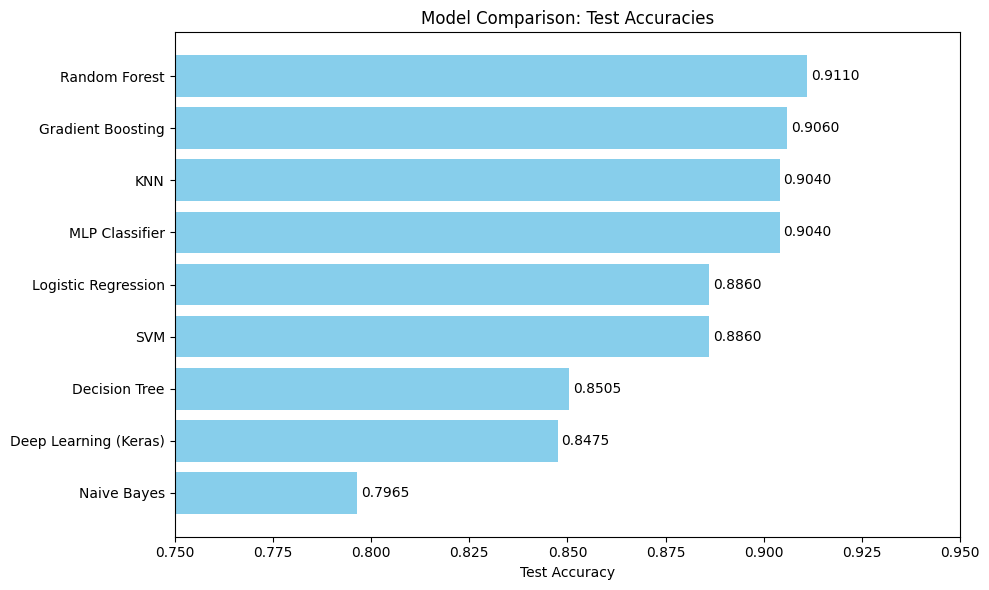

In [33]:
import matplotlib.pyplot as plt

accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Decision Tree": acc_dt,
    "SVM": accuracy_score(y_test, y_pred),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb_tuned),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "MLP Classifier": accuracy_score(y_test, y_pred_mlp),
    "Deep Learning (Keras)": test_acc
}

# Sort by accuracy for a nicer plot
accuracies = dict(sorted(accuracies.items(), key=lambda item: item[1], reverse=True))

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(list(accuracies.keys()), list(accuracies.values()), color='skyblue')
plt.xlabel("Test Accuracy")
plt.title("Model Comparison: Test Accuracies")
plt.xlim(0.75, 0.95)

# Annotate values
for i, (model, acc) in enumerate(accuracies.items()):
    plt.text(acc + 0.001, i, f"{acc:.4f}", va='center')

plt.gca().invert_yaxis()  # Highest accuracy on top
plt.tight_layout()
plt.show()


=== Random Forest (Tuned) ===
Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.99      0.99       461
           2       0.99      0.98      0.98       224
           3       0.88      0.94      0.91       397
           4       0.78      0.64      0.71       211
           5       0.92      0.89      0.91       237
           7       0.88      0.90      0.89       470

    accuracy                           0.91      2000
   macro avg       0.90      0.89      0.90      2000
weighted avg       0.91      0.91      0.91      2000



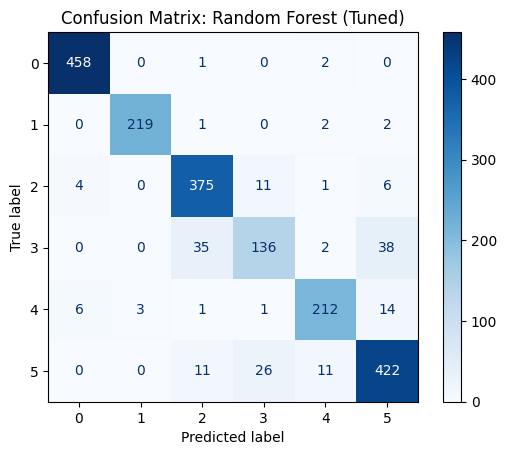


=== Gradient Boosting (Tuned) ===
Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.99      0.99       461
           2       0.97      0.97      0.97       224
           3       0.89      0.93      0.91       397
           4       0.75      0.65      0.70       211
           5       0.93      0.88      0.91       237
           7       0.87      0.89      0.88       470

    accuracy                           0.91      2000
   macro avg       0.90      0.89      0.89      2000
weighted avg       0.90      0.91      0.90      2000



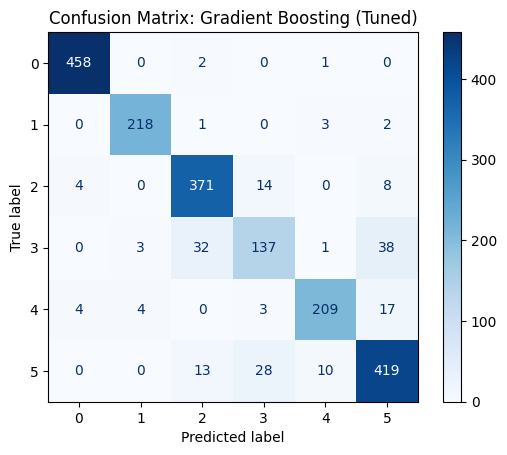


=== MLP Classifier ===
Classification Report:
              precision    recall  f1-score   support

           1       0.98      0.99      0.98       461
           2       0.97      0.96      0.97       224
           3       0.89      0.93      0.91       397
           4       0.76      0.65      0.70       211
           5       0.89      0.90      0.90       237
           7       0.88      0.88      0.88       470

    accuracy                           0.90      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.90      0.90      0.90      2000



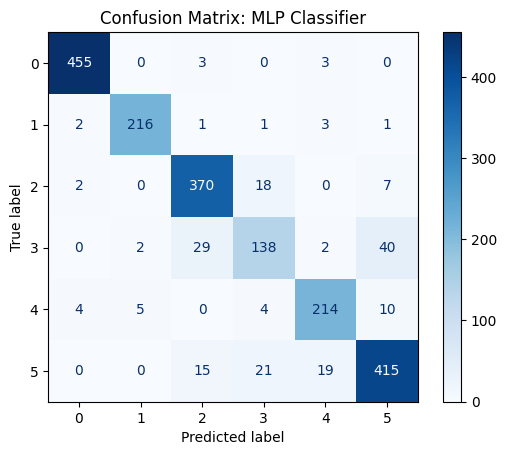

In [34]:
#Confusion Matrices & Classification Reports
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

top_models = {
    "Random Forest (Tuned)": y_pred_rf_tuned,
    "Gradient Boosting (Tuned)": y_pred_gb_tuned,
    "MLP Classifier": y_pred_mlp
}

for model_name, y_pred in top_models.items():
    print(f"\n=== {model_name} ===")

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()


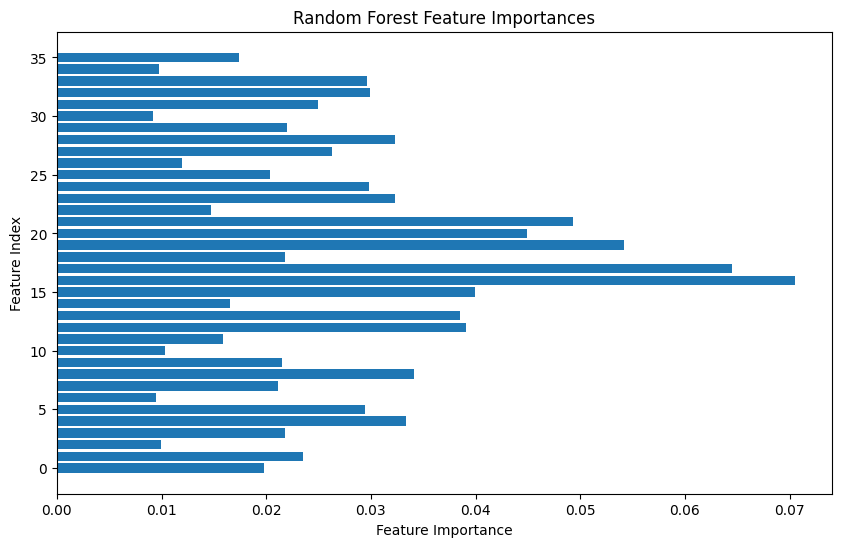

In [35]:
importances = grid_rf.best_estimator_.feature_importances_
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances, align='center')
plt.xlabel("Feature Importance")
plt.ylabel("Feature Index")
plt.title("Random Forest Feature Importances")
plt.show()


In [36]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Initialize the scaler
scaler = StandardScaler()

# Fit scaler on training data and transform both training and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create SVM classifier
svm_clf = SVC()

# Train the model on scaled data
svm_clf.fit(X_train_scaled, y_train)

# Predict on scaled test data
y_pred = svm_clf.predict(X_test_scaled)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"SVM Test Accuracy (scaled data): {accuracy:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))


SVM Test Accuracy (scaled data): 0.8955

Classification Report:
               precision    recall  f1-score   support

           1       0.98      1.00      0.99       461
           2       0.96      0.97      0.97       224
           3       0.87      0.96      0.92       397
           4       0.72      0.58      0.64       211
           5       0.93      0.86      0.89       237
           7       0.85      0.86      0.86       470

    accuracy                           0.90      2000
   macro avg       0.89      0.87      0.88      2000
weighted avg       0.89      0.90      0.89      2000



cross validation for logistic regression (result dropped)

In [41]:
from sklearn.model_selection import cross_val_score

# Initialize logistic regression
model = LogisticRegression(max_iter=1000, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

# Print the cross-validation accuracy
print("Logistic Regression CV Accuracy:", cv_scores.mean())

Logistic Regression CV Accuracy: 0.8243517474633597
